# Fashion Product Image Classification

In [1]:
# Import libraries
import kagglehub
import os
import pandas as pd
import numpy as np
import random
import keras
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from keras.layers import RandomFlip, RandomRotation, RandomZoom
from keras.callbacks import EarlyStopping
from keras.layers import SpatialDropout2D


os.environ['TF_DETERMINISTIC_OPS'] = '1' # ensures deterministic GPU operations
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

**Data Preprocessing**

In [2]:
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# Download latest version
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("Path to dataset files:", path)

100%|██████████| 565M/565M [00:26<00:00, 22.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1


In [4]:
# List files in the downloaded path to identify the data file
print("Files in the dataset directory:")
for file in os.listdir(path):
    print(file)

Files in the dataset directory:
images
myntradataset
styles.csv


In [5]:
# Construct the full path to the CSV file
csv_file_path = os.path.join(path, 'styles.csv')

# Load the CSV file into a pandas DataFrame, ignoring malformed rows
df = pd.read_csv(csv_file_path, on_bad_lines='skip')

# Construct the full path to the images directory
images_dir = os.path.join(path, 'images')

# Create a new column 'image_path' with the full path to each image
df['image_path'] = df['id'].apply(lambda x: os.path.join(images_dir, str(x) + '.jpg'))

In [6]:
# Filter out rows where the image file does not exist
initial_rows = len(df)
df = df[df['image_path'].apply(lambda x: os.path.exists(x))]
print(f"Removed {initial_rows - len(df)} rows where image files were not found.")

# Check for missing values in 'masterCategory' and drop them if any
if df['masterCategory'].isnull().any():
    initial_mc_rows = len(df)
    df.dropna(subset=['masterCategory'], inplace=True)
    print(f"Removed {initial_mc_rows - len(df)} rows with missing 'masterCategory'.")

Removed 5 rows where image files were not found.


In [7]:
# Display the updated DataFrame info and head to verify
print("\nDataFrame after mapping images and cleaning:\n")
print(df.info())
print('============================================================')
print(df.head())


DataFrame after mapping images and cleaning:

<class 'pandas.core.frame.DataFrame'>
Index: 44419 entries, 0 to 44423
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44419 non-null  int64  
 1   gender              44419 non-null  object 
 2   masterCategory      44419 non-null  object 
 3   subCategory         44419 non-null  object 
 4   articleType         44419 non-null  object 
 5   baseColour          44404 non-null  object 
 6   season              44398 non-null  object 
 7   year                44418 non-null  float64
 8   usage               44102 non-null  object 
 9   productDisplayName  44412 non-null  object 
 10  image_path          44419 non-null  object 
dtypes: float64(1), int64(1), object(9)
memory usage: 4.1+ MB
None
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue 

In [8]:
# Display number of images in each category
category_counts = df['masterCategory'].value_counts()
category_counts

,count
masterCategory,
Apparel,21392
Accessories,11274
Footwear,9219
Personal Care,2403
Free Items,105
Sporting Goods,25
Home,1


In [9]:
# Drop Personal Care, Free Items, Sporting Goods and Home categories because they don't have many images
df = df[df['masterCategory'] != 'Personal Care']
df = df[df['masterCategory'] != 'Free Items']
df = df[df['masterCategory'] != 'Sporting Goods']
df = df[df['masterCategory'] != 'Home']

#Display categories after dropping
category_counts = df['masterCategory'].value_counts()
category_counts

,count
masterCategory,
Apparel,21392
Accessories,11274
Footwear,9219


In [10]:
# Encode 'masterCategory' labels
le = LabelEncoder()
df['masterCategory_encoded'] = le.fit_transform(df['masterCategory'])

In [11]:
# Create subset with balanced classes
samples_per_class = 6600

balanced_df = df.groupby('masterCategory').apply(
    lambda x: x.sample(min(len(x), samples_per_class), random_state=42)
).reset_index(drop=True)

print("Samples per category after balancing:")
print(balanced_df['masterCategory'].value_counts())
print(f"\nTotal samples: {len(balanced_df)}")

X_balanced = balanced_df['image_path']
y_balanced = le.transform(balanced_df['masterCategory'])

# Split into train, validation, and test sets (70% train, 30% temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_balanced, y_balanced,
    test_size=0.3,
    random_state=42,
    stratify=y_balanced
)

# Split X_temp into validation and test sets (15% val, 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"Total samples in the final splits: {len(X_train) + len(X_val) + len(X_test)}")

Samples per category after balancing:
masterCategory
Accessories    6600
Apparel        6600
Footwear       6600
Name: count, dtype: int64

Total samples: 19800

Training set size: 13860 samples
Validation set size: 2970 samples
Test set size: 2970 samples
Total samples in the final splits: 19800


/tmp/ipykernel_495/2619036289.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('masterCategory').apply(


In [12]:
# Show pixel value range
# Select a random image path from the DataFrame
random_image_path = df.sample(1)['image_path'].iloc[0]
img = image.load_img(random_image_path)
img_array = image.img_to_array(img)
print("Min pixel value:", np.min(img_array))
print("Max pixel value:", np.max(img_array))

Min pixel value: 0.0
Max pixel value: 255.0


In [13]:
# Resize and normalize images

image_size = (128, 128)
batch_size = 32

def preprocess_images(image_paths, labels, image_size):
    images = []
    for path in image_paths:
        img = load_img(path, target_size=image_size) # Resize images
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        images.append(img_array)
    return np.array(images), np.array(labels)

# Preprocess training, test and validation data
X_train_processed, y_train_processed = preprocess_images(X_train, y_train, image_size)
X_test_processed, y_test_processed = preprocess_images(X_test, y_test, image_size)
X_val_processed, y_val_processed = preprocess_images(X_val, y_val, image_size)

**Data Visualization**

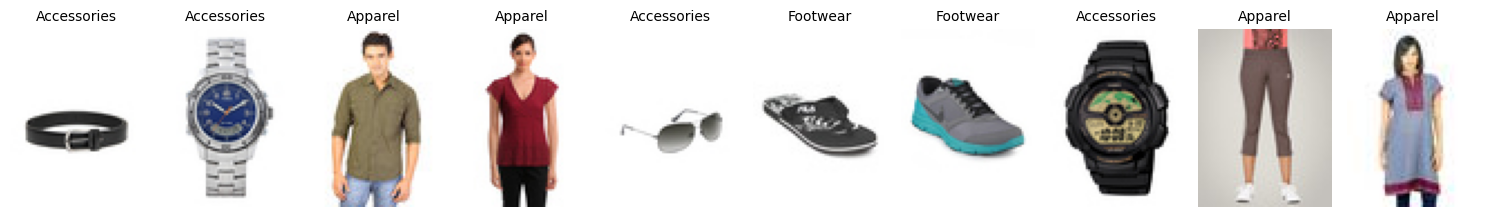

In [19]:
# Display sample images
num_samples_to_display = 10
plt.figure(figsize=(15, 5))

samples = balanced_df.sample(num_samples_to_display)

for i, (idx, row) in enumerate(samples.iterrows()):
    try:
        # Load and show
        img = Image.open(row['image_path'])

        plt.subplot(1, num_samples_to_display, i + 1)
        plt.imshow(img)
        plt.title(row['masterCategory'], fontsize=10)
        plt.axis('off')
    except Exception as e:
        print(f"Could not load image at {row['image_path']}: {e}")

plt.tight_layout()
plt.show()

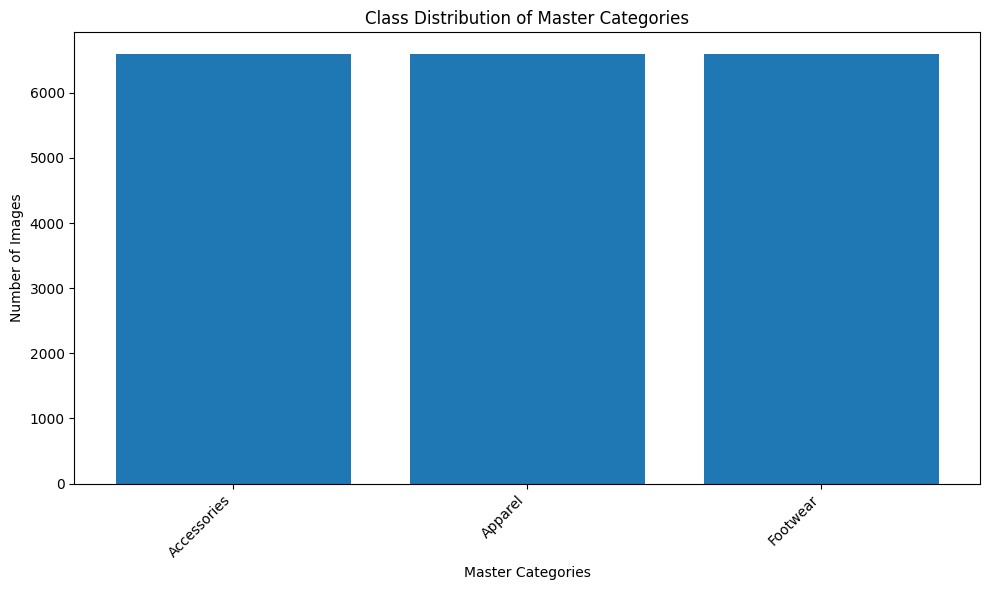

In [20]:
# Display class distribution
classes = balanced_df['masterCategory'].value_counts().index
counts = balanced_df['masterCategory'].value_counts().values

plt.figure(figsize=(10, 6))
plt.bar(classes, counts)
plt.title("Class Distribution of Master Categories")
plt.xlabel("Master Categories")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Model Design**

In [21]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(le.classes_), activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
# Display CNN layers
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,779 (32.36 MB)

 Trainable params: 8,483,331 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

**Model Training**

In [23]:
# Compile model
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

In [24]:
# Train model
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train_processed, y_train_processed,
    validation_data=(X_val_processed, y_val_processed),
    epochs=30,
    batch_size=batch_size,
    callbacks=[early_stop]  # training stops when val_loss plateaus
  )

Epoch 1/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.9260 - loss: 0.5994 - val_accuracy: 0.9532 - val_loss: 0.1708
Epoch 2/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.9490 - loss: 0.1898 - val_accuracy: 0.7549 - val_loss: 2.1022
Epoch 3/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9619 - loss: 0.1331 - val_accuracy: 0.8192 - val_loss: 1.1648
Epoch 4/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9653 - loss: 0.1175 - val_accuracy: 0.8882 - val_loss: 0.2734
Epoch 5/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9696 - loss: 0.1140 - val_accuracy: 0.8741 - val_loss: 0.6422
Epoch 6/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9706 - loss: 0.1071 - val_accuracy: 0.9721 - val_loss: 0.1105
Epoch 7/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9734 - loss: 0.0990 - val_accuracy: 0.9667 - val_loss: 0.1667
Epoch 8/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9750 - loss: 0.0963 - 

**Evaluation**

In [25]:
# Display accuracy
test_loss, test_acc = model.evaluate(X_test_processed, y_test_processed)
print("Test Accuracy:", test_acc)
print("Best Validation Accuracy:", max(history.history['val_accuracy']))

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9751 - loss: 0.1023
Test Accuracy: 0.9750841856002808
Best Validation Accuracy: 0.9720538854598999


93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


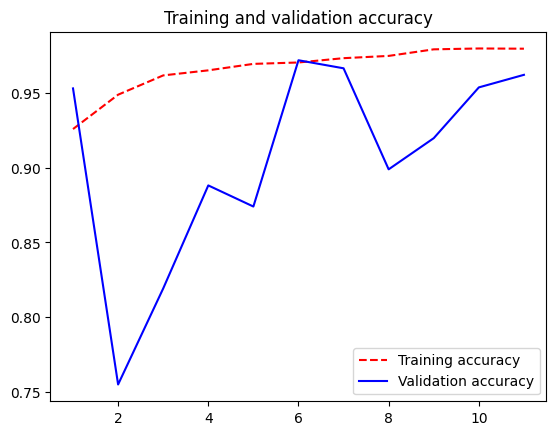

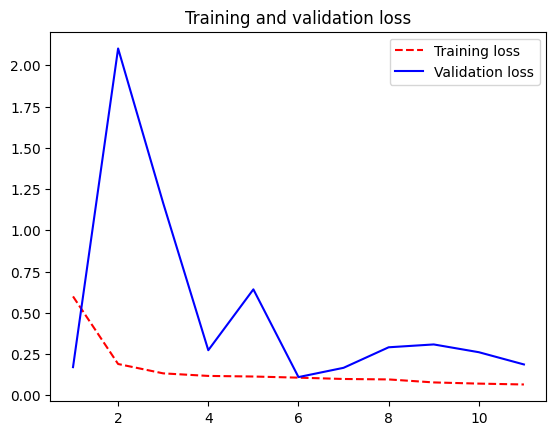

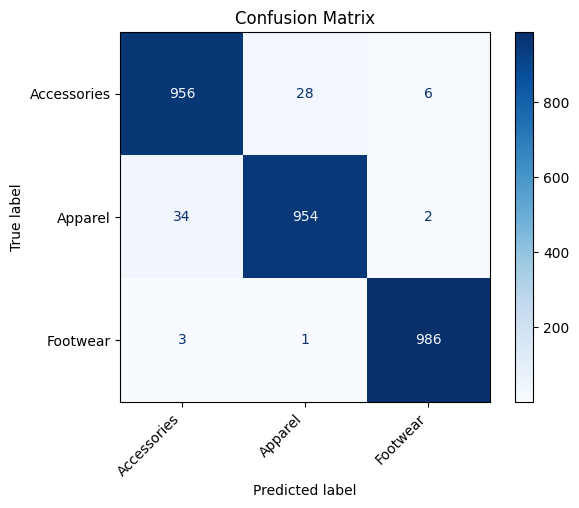

In [26]:
# Make predictions on the test set
y_pred_probs = model.predict(X_test_processed)
y_pred = np.argmax(y_pred_probs, axis=1)

# Display accuracy and loss
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()

plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

# Compute confusion matrix
cm = confusion_matrix(y_test_processed, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


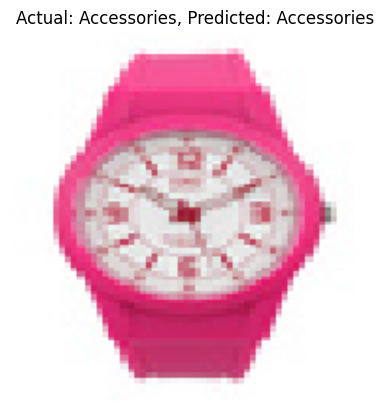

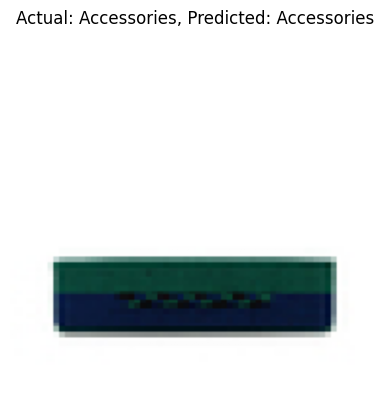

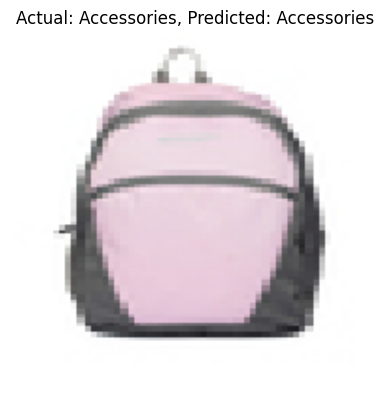

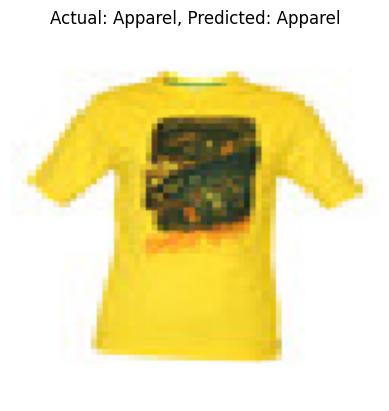

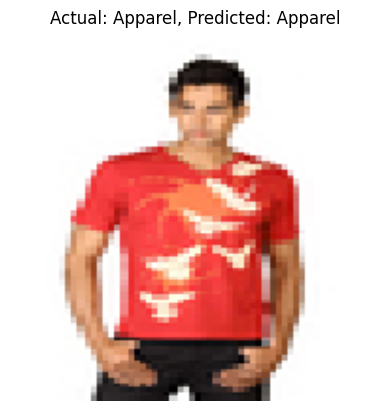

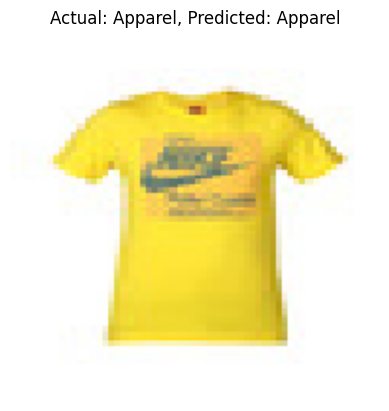

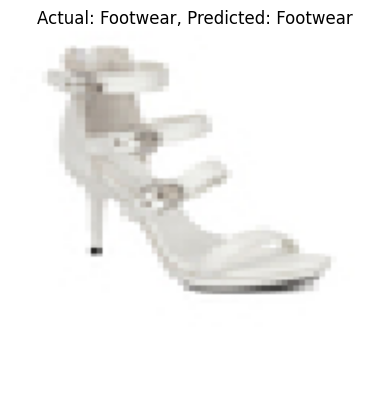

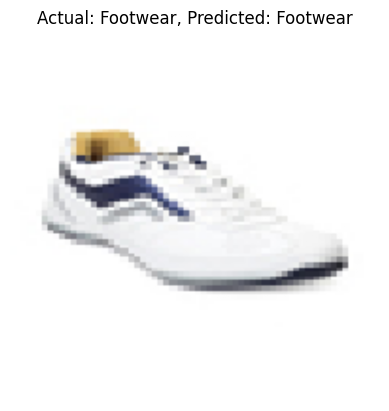

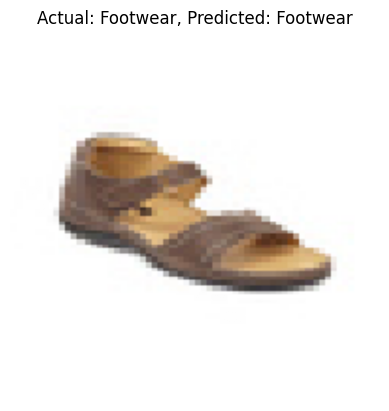

In [28]:
# Display predicted vs actual labels
y_pred_probs = model.predict(X_test_processed)

samples_per_category = 3  # shows 3 examples per class

sample_indices = []
for class_idx in range(len(le.classes_)):
    class_indices = np.where(y_test_processed == class_idx)[0]
    sample_indices.extend(np.random.choice(class_indices, samples_per_category, replace=False))

predicted_labels = le.inverse_transform(np.argmax(y_pred_probs, axis=1))

for i in sample_indices:
    plt.imshow(X_test_processed[i])
    plt.title(f"Actual: {le.inverse_transform([y_test_processed[i]])[0]}, Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()

**Improvement**

In [29]:
# Add data augmentation and lower dropout to 0.3
model_aug = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

# Compile model
model_aug.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# Train model
early_stop_aug = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_aug = model_aug.fit(
    X_train_processed, y_train_processed,
    validation_data=(X_val_processed, y_val_processed),
    epochs=30,
    batch_size=batch_size,
    callbacks=[early_stop_aug]
  )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 29s 54ms/step - accuracy: 0.8280 - loss: 0.8239 - val_accuracy: 0.7936 - val_loss: 0.7086
Epoch 2/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.8959 - loss: 0.3164 - val_accuracy: 0.8582 - val_loss: 0.8458
Epoch 3/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 40s 50ms/step - accuracy: 0.9282 - loss: 0.2182 - val_accuracy: 0.8956 - val_loss: 0.3079
Epoch 4/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.9343 - loss: 0.2120 - val_accuracy: 0.8919 - val_loss: 0.4229
Epoch 5/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9381 - loss: 0.2054 - val_accuracy: 0.8808 - val_loss: 0.3522
Epoch 6/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9449 - loss: 0.1649 - val_accuracy: 0.8943 - val_loss: 0.3036
Epoch 7/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9504 - loss: 0.1589 - val_accuracy: 0.7687 - val_loss: 1.4265
Epoch 8/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.9547 - loss: 0.1475 - 

In [30]:
# Display accuracy
test_loss, test_acc = model_aug.evaluate(X_test_processed, y_test_processed)
print("Test Accuracy:", test_acc)
print("Best Validation Accuracy:", max(history_aug.history['val_accuracy']))

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9694 - loss: 0.1083
Test Accuracy: 0.9693602919578552
Best Validation Accuracy: 0.9744107723236084


In [31]:
# Add dropout
model_drop = Sequential([
  Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
  BatchNormalization(),
  MaxPooling2D(2,2),
  SpatialDropout2D(0.1),   # drops entire feature maps
  Conv2D(64, (3,3), activation='relu', padding='same'),
  BatchNormalization(),
  MaxPooling2D(2,2),
  SpatialDropout2D(0.2),
  Conv2D(128, (3,3), activation='relu', padding='same'),
  BatchNormalization(),
  MaxPooling2D(2,2),
  SpatialDropout2D(0.3),   # increase rate as depth increases
  Flatten(),
  Dense(256, activation='relu'),
  Dropout(0.3),
  Dense(len(le.classes_), activation='softmax')
])

# Compile model
model_drop.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# Train model
early_stop_drop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_drop = model_drop.fit(
    X_train_processed, y_train_processed,
    validation_data=(X_val_processed, y_val_processed),
    epochs=30,
    batch_size=batch_size,
    callbacks=[early_stop_drop]
  )

Epoch 1/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.9262 - loss: 0.5415 - val_accuracy: 0.9657 - val_loss: 0.1257
Epoch 2/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9556 - loss: 0.1709 - val_accuracy: 0.9646 - val_loss: 0.1326
Epoch 3/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9628 - loss: 0.1488 - val_accuracy: 0.9724 - val_loss: 0.0850
Epoch 4/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9665 - loss: 0.1331 - val_accuracy: 0.9673 - val_loss: 0.1199
Epoch 5/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9732 - loss: 0.0969 - val_accuracy: 0.9256 - val_loss: 0.6476
Epoch 6/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9713 - loss: 0.1044 - val_accuracy: 0.9721 - val_loss: 0.1292
Epoch 7/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9737 - loss: 0.1066 - val_accuracy: 0.8805 - val_loss: 1.1229
Epoch 8/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 59ms/step - accuracy: 0.9728 - loss: 0.0983 - 

In [32]:
# Display accuracy
test_loss, test_acc = model_drop.evaluate(X_test_processed, y_test_processed)
print("Test Accuracy:", test_acc)
print("Best Validation Accuracy:", max(history_drop.history['val_accuracy']))

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9690 - loss: 0.0937
Test Accuracy: 0.969023585319519
Best Validation Accuracy: 0.9771043658256531


In [33]:
# Combine data augmentation and dropout
model_comb = Sequential([
  RandomFlip("horizontal"),
  RandomRotation(0.1),
  RandomZoom(0.1),
  Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
  BatchNormalization(),
  MaxPooling2D(2,2),
  SpatialDropout2D(0.1),   # drops entire feature maps
  Conv2D(64, (3,3), activation='relu', padding='same'),
  BatchNormalization(),
  MaxPooling2D(2,2),
  SpatialDropout2D(0.2),
  Conv2D(128, (3,3), activation='relu', padding='same'),
  BatchNormalization(),
  MaxPooling2D(2,2),
  SpatialDropout2D(0.3),   # increase rate as depth increases
  Flatten(),
  Dense(256, activation='relu'),
  Dropout(0.3),
  Dense(len(le.classes_), activation='softmax')
])

# Compile model
model_comb.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# Train model
early_stop_comb = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_comb = model_comb.fit(
    X_train_processed, y_train_processed,
    validation_data=(X_val_processed, y_val_processed),
    epochs=30,
    batch_size=batch_size,
    callbacks=[early_stop_comb]
  )

Epoch 1/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 34s 65ms/step - accuracy: 0.7970 - loss: 0.8537 - val_accuracy: 0.8242 - val_loss: 0.5798
Epoch 2/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.8776 - loss: 0.3402 - val_accuracy: 0.7990 - val_loss: 1.1494
Epoch 3/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.8998 - loss: 0.2905 - val_accuracy: 0.5219 - val_loss: 4.5074
Epoch 4/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9124 - loss: 0.2685 - val_accuracy: 0.9347 - val_loss: 0.2464
Epoch 5/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.9151 - loss: 0.2669 - val_accuracy: 0.9300 - val_loss: 0.2269
Epoch 6/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9233 - loss: 0.2439 - val_accuracy: 0.8929 - val_loss: 0.3424
Epoch 7/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.9312 - loss: 0.2119 - val_accuracy: 0.9377 - val_loss: 0.2115
Epoch 8/30
434/434 ━━━━━━━━━━━━━━━━━━━━ 26s 60ms/step - accuracy: 0.9318 - loss: 0.2133 - 

In [34]:
# Display accuracy
test_loss, test_acc = model_comb.evaluate(X_test_processed, y_test_processed)
print("Test Accuracy:", test_acc)
print("Best Validation Accuracy:", max(history_comb.history['val_accuracy']))

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9545 - loss: 0.1422
Test Accuracy: 0.9545454382896423
Best Validation Accuracy: 0.9653198719024658


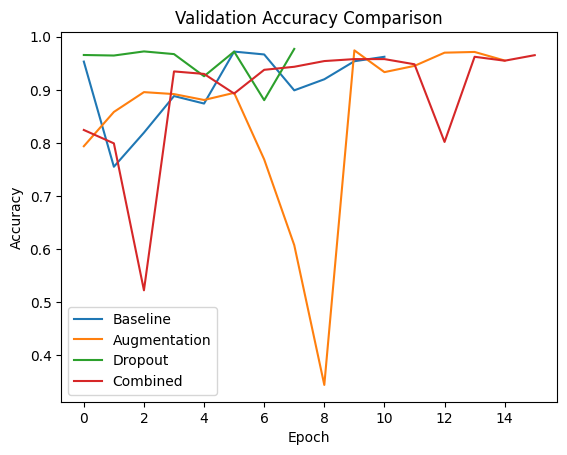

In [35]:
# Plot all val_accuracy curves together
plt.plot(history.history['val_accuracy'], label='Baseline')
plt.plot(history_aug.history['val_accuracy'], label='Augmentation')
plt.plot(history_drop.history['val_accuracy'], label='Dropout')
plt.plot(history_comb.history['val_accuracy'], label='Combined')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


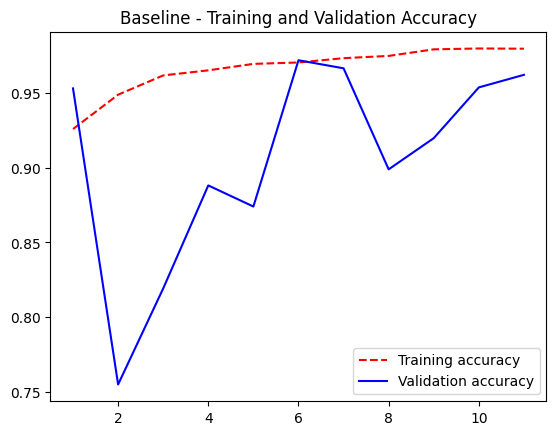

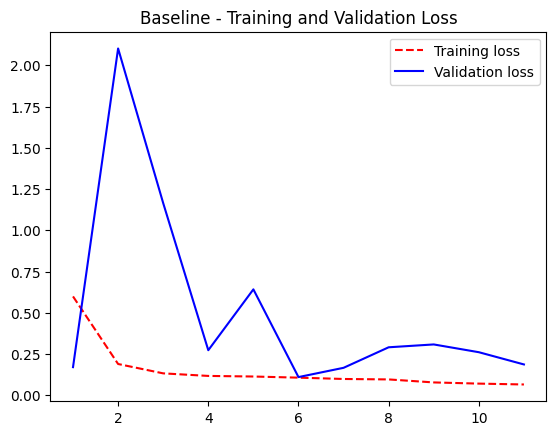

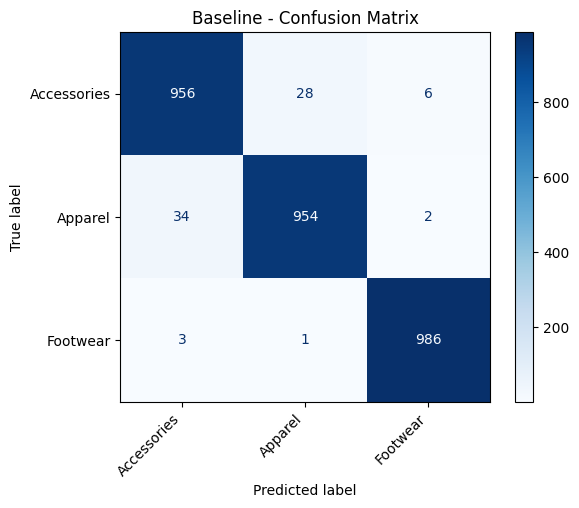

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


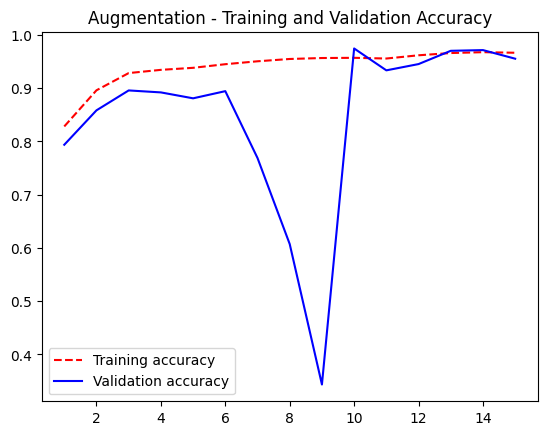

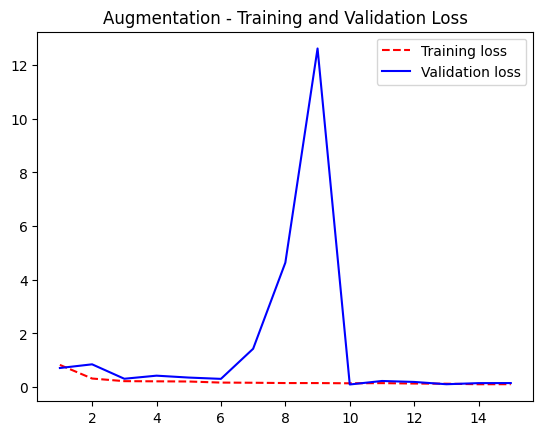

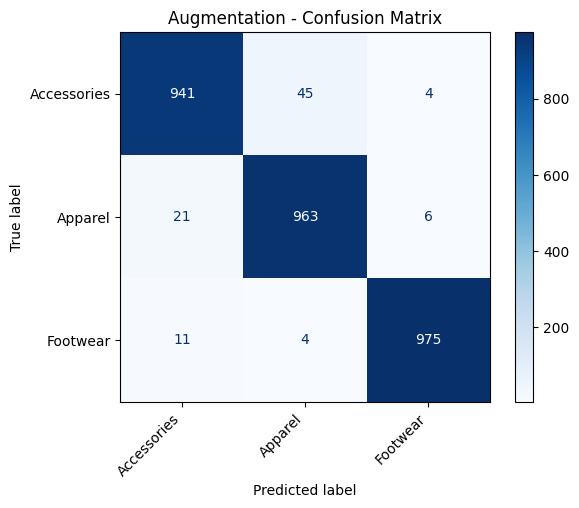

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


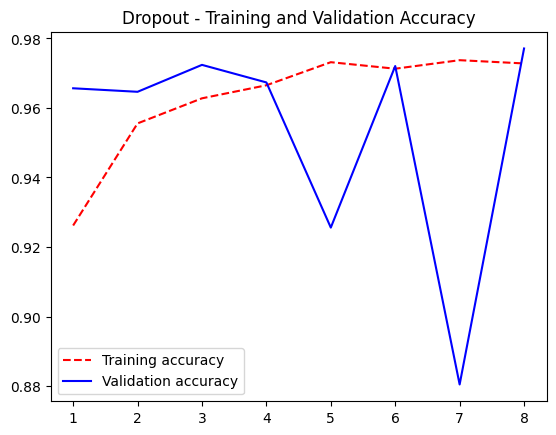

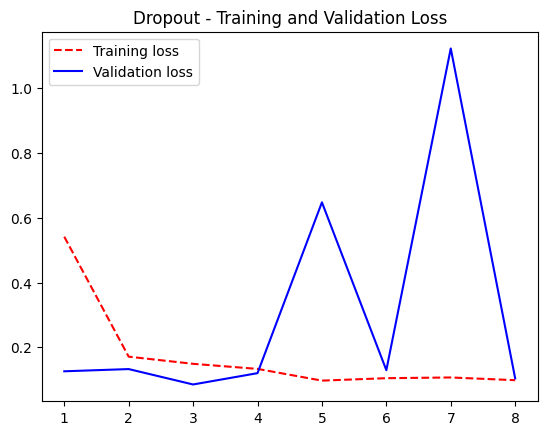

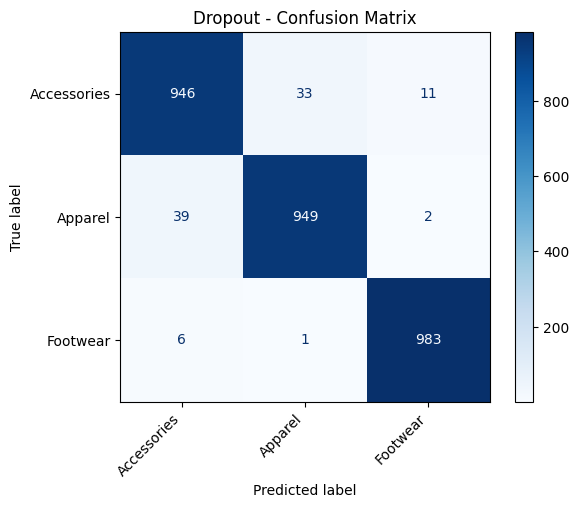

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


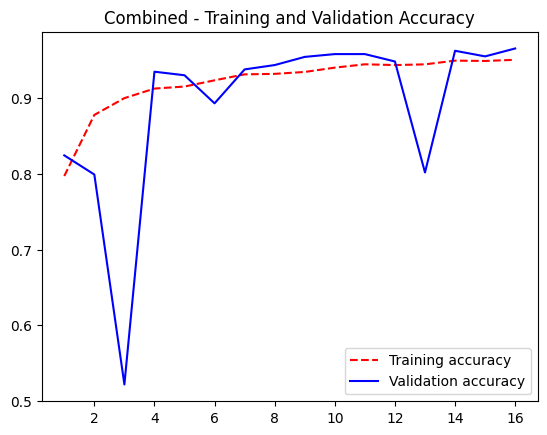

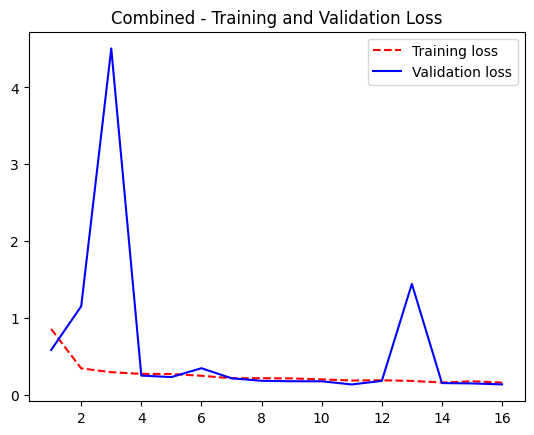

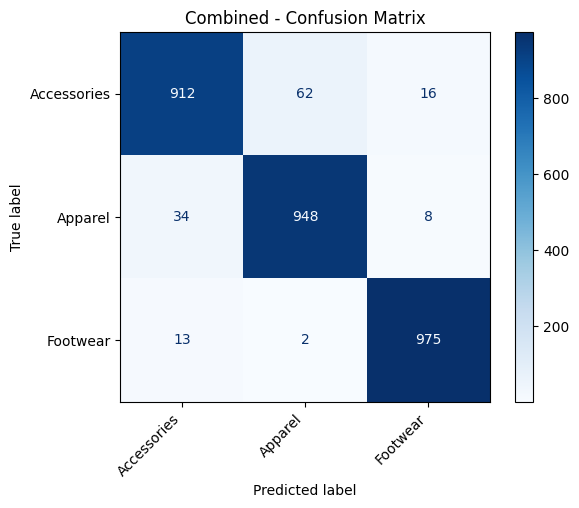

In [36]:
# Display accuracy, loss and confusion matrix for each model
def evaluate_model(model, history, name):
    # Make predictions
    y_pred_probs = model.predict(X_test_processed)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Accuracy and loss plots
    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(accuracy) + 1)

    plt.plot(epochs, accuracy, "r--", label="Training accuracy")
    plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
    plt.title(f"{name} - Training and Validation Accuracy")
    plt.legend()
    plt.figure()

    plt.plot(epochs, loss, "r--", label="Training loss")
    plt.plot(epochs, val_loss, "b", label="Validation loss")
    plt.title(f"{name} - Training and Validation Loss")
    plt.legend()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_test_processed, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{name} - Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Call for each model
evaluate_model(model, history, "Baseline")
evaluate_model(model_aug, history_aug, "Augmentation")
evaluate_model(model_drop, history_drop, "Dropout")
evaluate_model(model_comb, history_comb, "Combined")

In [37]:
# Display gap in training accuracy and validation accuracy for each model
models = {
    'Baseline': history,
    'Augmentation': history_aug,
    'Dropout': history_drop,
    'Combined': history_comb
}

print(f"{'Model':<15} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>10}")
print("-" * 50)
for name, hist in models.items():
    train_acc = max(hist.history['accuracy'])
    val_acc = max(hist.history['val_accuracy'])
    gap = train_acc - val_acc
    print(f"{name:<15} {train_acc:>10.4f} {val_acc:>10.4f} {gap:>10.4f}")

Model            Train Acc    Val Acc        Gap
--------------------------------------------------
Baseline            0.9799     0.9721     0.0079
Augmentation        0.9675     0.9744    -0.0070
Dropout             0.9737     0.9771    -0.0034
Combined            0.9504     0.9653    -0.0150


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


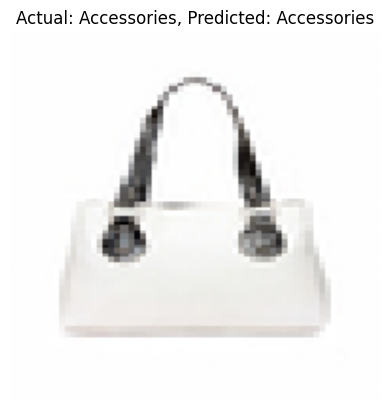

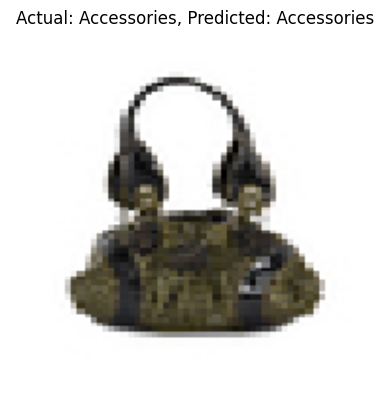

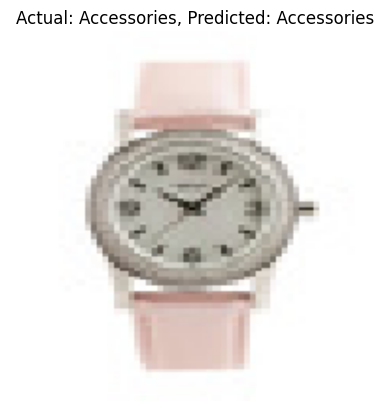

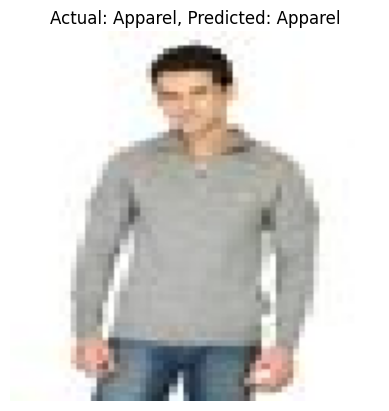

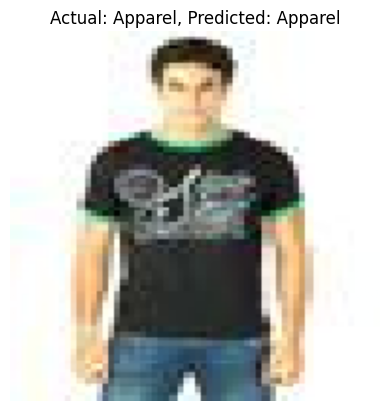

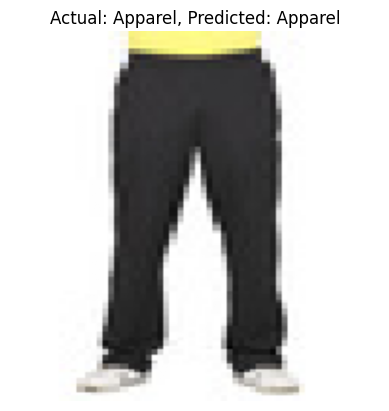

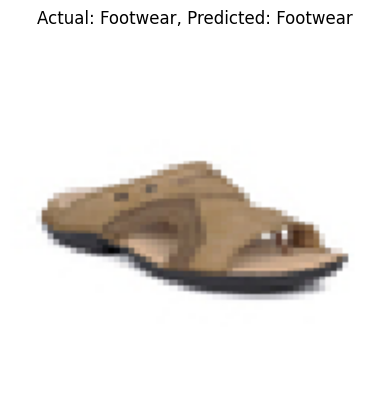

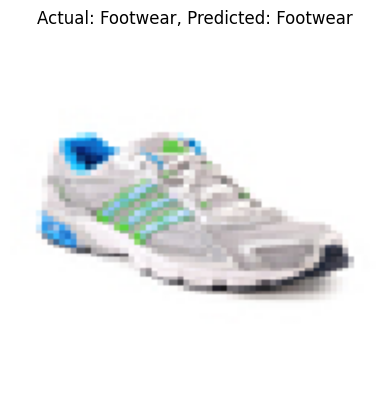

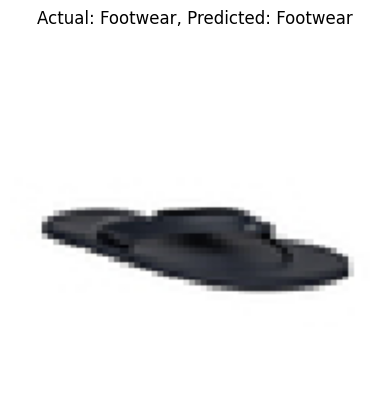

In [39]:
# Display predicted vs actual labels
y_pred_probs = model_comb.predict(X_test_processed)

samples_per_category = 3  # shows 3 examples per class

sample_indices = []
for class_idx in range(len(le.classes_)):
    class_indices = np.where(y_test_processed == class_idx)[0]
    sample_indices.extend(np.random.choice(class_indices, samples_per_category, replace=False))

predicted_labels = le.inverse_transform(np.argmax(y_pred_probs, axis=1))

for i in sample_indices:
    plt.imshow(X_test_processed[i])
    plt.title(f"Actual: {le.inverse_transform([y_test_processed[i]])[0]}, Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()

**Result Interpretation**

Key Takeaways
* The baseline model achieved excellent validation accuracy with a small gap between training accuracy and validation accuracy, indicating very slight overfitting.
* Adding augmentation to the baseline model achieved slightly higher accuracy than the baseline, and the negative train-val gap indicates no overfitting.
* Adding dropout only (without augmentation) to the baseline model achieved slightly better accuracy than all other models, and a negative train-val gap, indicating no overfitting.
* The best performing model is the combination of augmentation and dropout. It has an excellent validation accuracy and the largest negative train-val gap indicating that the model generalizes well on the validation data and there is no overfitting. It is most balanced for accuracy without overfitting, and most effective at classifying fashion product images.